# Netflix Content Storytelling Analysis

## Audience
Non-technical audience

## Objective
Explore Netflix’s content library to understand how the catalog has grown, what types of content dominate, and what trends appear across countries, genres, and release years.

## Questions Investigated
- How has Netflix content changed over time?
- Does Netflix favor movies or TV shows?
- Which countries contribute the most content?
- What genres dominate Netflix?
- Does Netflix focus more on recent releases?

## Hypothesis
Netflix has rapidly expanded its catalog over time, with movies, recent releases, and international content playing major roles in the platform’s content strategy.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_titles.csv', encoding='latin1')

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Data Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8809 non-null   object 
 1   type          8809 non-null   object 
 2   title         8809 non-null   object 
 3   director      6175 non-null   object 
 4   cast          7984 non-null   object 
 5   country       7978 non-null   object 
 6   date_added    8799 non-null   object 
 7   release_year  8809 non-null   int64  
 8   rating        8805 non-null   object 
 9   duration      8806 non-null   object 
 10  listed_in     8809 non-null   object 
 11  description   8809 non-null   object 
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   0 non-null      float64
 14  Unnamed: 14   0 non-null      float64
 15  Unnamed: 15   0 non-null      float64
 16  Unnamed: 16   0 non-null      float64
 17  Unnamed: 17   0 non-null      float64
 18  Unnamed: 18   0 non-null    

In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
Unnamed: 12     8809
Unnamed: 13     8809
Unnamed: 14     8809
Unnamed: 15     8809
Unnamed: 16     8809
Unnamed: 17     8809
Unnamed: 18     8809
Unnamed: 19     8809
Unnamed: 20     8809
Unnamed: 21     8809
Unnamed: 22     8809
Unnamed: 23     8809
Unnamed: 24     8809
Unnamed: 25     8809
dtype: int64

## Data Preparation

In [6]:
df['date_added'] = pd.to_datetime(
    df['date_added'].str.strip(),
    format='mixed',
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

In [7]:
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


### Question 1: Does Netflix favor movies or TV shows?

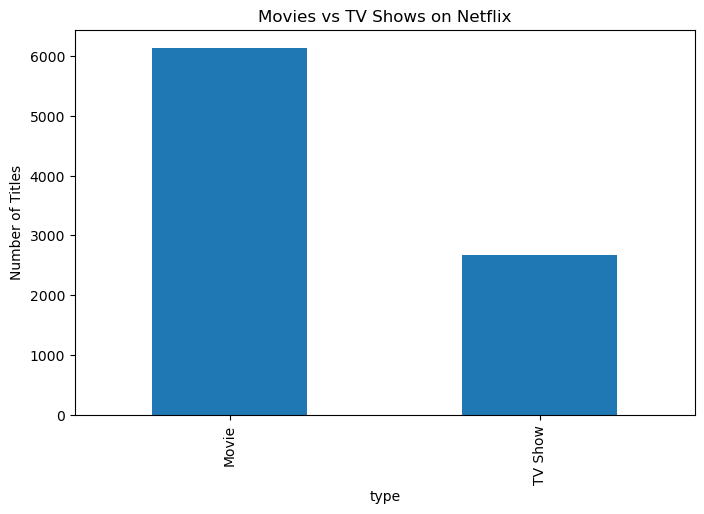

In [8]:
df['type'].value_counts().plot(kind='bar', figsize=(8,5))

plt.title('Movies vs TV Shows on Netflix')
plt.ylabel('Number of Titles')
plt.show()

Netflix contains more movies than TV shows, suggesting that movies make up the largest share of the platform’s catalog.

### Question 2: How has Netflix content grown over time?

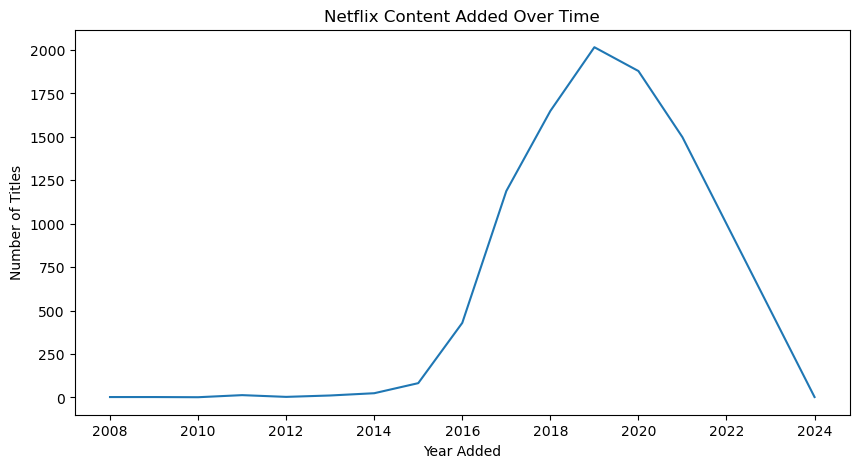

In [9]:
df['year_added'].value_counts().sort_index().plot(figsize=(10,5))

plt.title('Netflix Content Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

The number of titles added to Netflix increased sharply in recent years, showing the platform’s rapid catalog expansion.

### Question 3: Which countries contribute the most Netflix content?

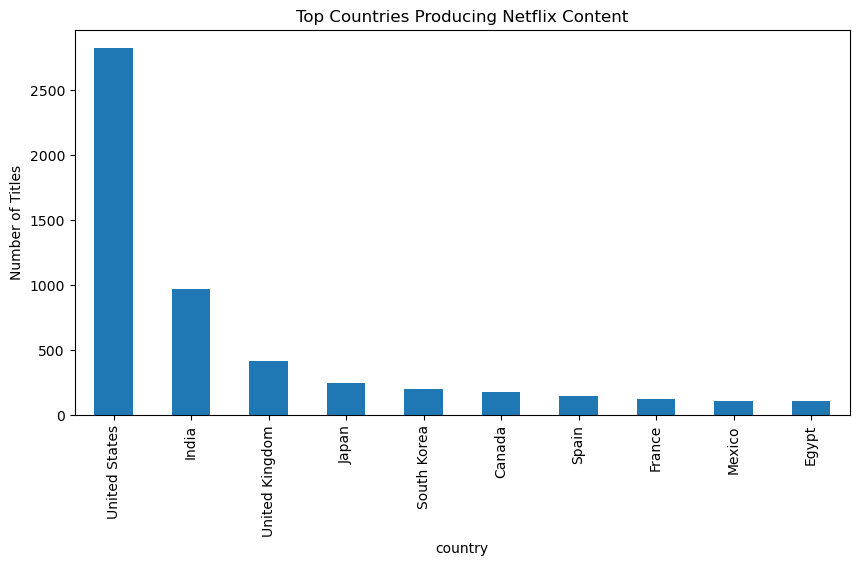

In [10]:
df['country'].value_counts().head(10).plot(kind='bar', figsize=(10,5))

plt.title('Top Countries Producing Netflix Content')
plt.ylabel('Number of Titles')
plt.show()

The United States contributes the most Netflix content, though the platform includes content from many international markets.

### Question 4: What genres dominate Netflix?

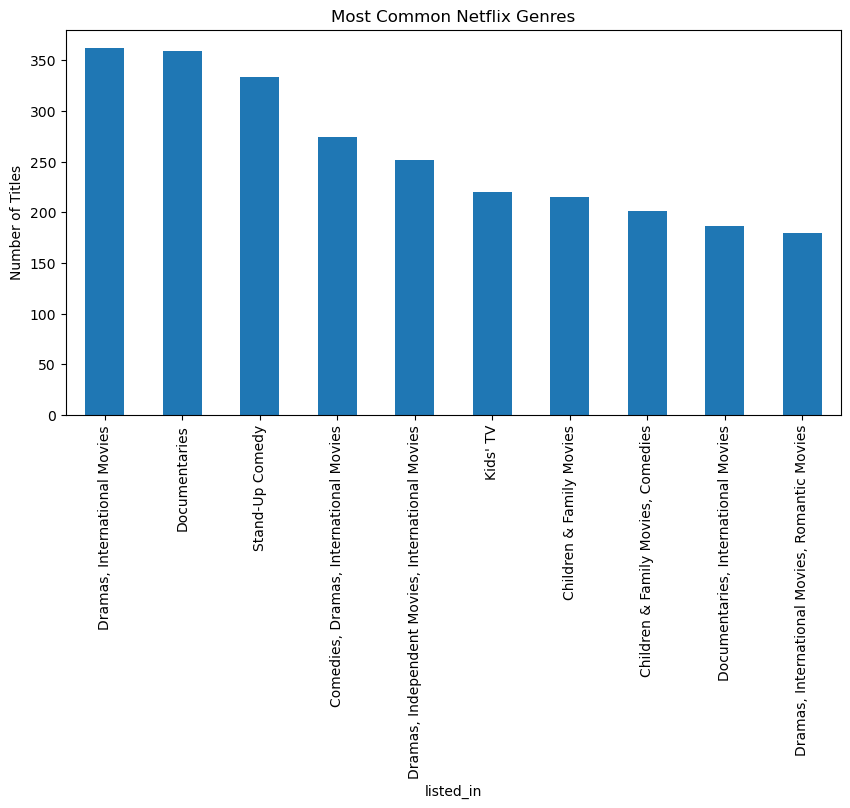

In [11]:
df['listed_in'].value_counts().head(10).plot(kind='bar', figsize=(10,5))

plt.title('Most Common Netflix Genres')
plt.ylabel('Number of Titles')
plt.show()

Several genre categories dominate the catalog, suggesting Netflix’s library is concentrated around specific audience interests.

### Question 5: Does Netflix focus on recent releases?

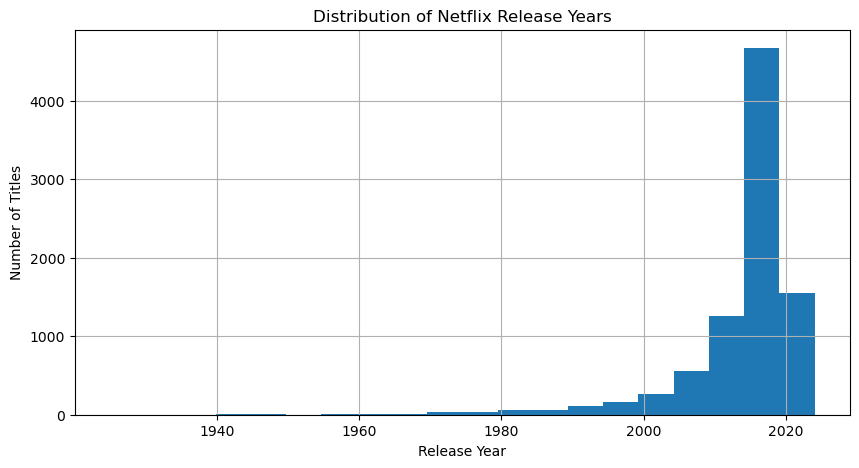

In [12]:
df['release_year'].hist(bins=20, figsize=(10,5))

plt.title('Distribution of Netflix Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

Netflix’s catalog is concentrated around more recent release years, suggesting a strong focus on modern content.

## Conclusion

This analysis found that Netflix’s catalog is heavily weighted toward movies, modern releases, and content added during recent years. The platform also draws heavily from the United States while maintaining a broad international content base.

Overall, the data suggests that Netflix’s content strategy emphasizes rapid catalog growth, global reach, and frequent additions of recent titles.